In [1]:
library(readxl)
library(readr)
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggrepel)
library(networkD3)
library(tibble)
library(ggalluvial)
library(RColorBrewer)
library(scales)
library(viridis)
library(car)

Warning message:
“package ‘readxl’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘networkD3’ was built under R version 4.3.3”
Warning message:
“package ‘ggalluvial’ was built under R version 4.3.3”
Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


Warning message:
“package ‘viridis’ was built under R version 4.3.3”
Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [2]:
load("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_gender.RData")

In [5]:
microbiome <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_microbiome_pathways.txt", header = TRUE, sep = "", stringsAsFactors = FALSE,check.names = FALSE)
head(microbiome)
dim(microbiome)
any(is.na(microbiome))
sum(is.na(microbiome))

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 425 524

[1] FALSE

[1] 0

In [10]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
rownames(basicPhenos) = basicPhenos$ID_500fg

## Filter a feature matrix and phenotype table to shared sample IDs and align rows in the same order
prep_filter_match <- function(feature_mat, basicPhenos) {
  idx <- rownames(feature_mat)[rownames(feature_mat) %in% rownames(basicPhenos)]  # keep feature_mat order
  feature_filter <- feature_mat[idx, , drop = FALSE]
  pheno_match <- basicPhenos[rownames(feature_filter), , drop = FALSE]
  list(feature_filter = feature_filter, basicPhenos_filter_match = pheno_match)
}
res <- prep_filter_match(microbiome, basicPhenos)
microbiome_filter <- res$feature_filter
basicPhenos_filter_match <- res$basicPhenos_filter_match
##one missing gender value
basicPhenos_filter_match$Gender <- trimws(basicPhenos_filter_match$Gender)
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

head(microbiome_filter)
dim(microbiome_filter)
head(basicPhenos_filter_match)
dim(basicPhenos_filter_match)

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 409 524

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
HV531,23,HV531,female,23,165,57,20.93664,Cohabitation,University student,European,Rarely,No,Yes,8,12,338,2014,Group 3
HV532,24,HV532,male,23,190,84,23.26870,Single living alone,University student,European,Once a month,Yes,Yes,8,12,338,2014,Group 3
HV533,25,HV533,female,24,173,60,20.04745,Cohabitation,University student,European,Rarely,No,Yes,8,12,338,2014,Group 4
HV534,26,HV534,male,22,174,74,24.44180,Cohabitation,University student,European,Daily,No,No,8,12,338,2014,Group 3
HV305,533,HV305,female,23,174,69,22.79033,Single living alone,University student,European,Once a month,No,Yes,NA,NA,NA,NA,Group 3
HV352,296,HV352,male,25,180,84,25.92593,Cohabitation,University student,European,Daily,No,No,28,7,208,2014,Group 4


[1] 409  18

In [26]:
bad_cols <- which(apply(microbiome_filter, 2, function(x) any(x <= -1, na.rm = TRUE)))
length(bad_cols)
colnames(microbiome_filter)[bad_cols][1:10]
j <- bad_cols[1]
x <- microbiome_filter[, j]
summary(x)
range(x, na.rm = TRUE)
which(x < -1)              # 这些行会导致 NaN
x[x < -1][1:20]            # 看前 20 个触发值
rownames(microbiome_filter)[which(x < -1)][1:20]  # 对应样本ID   
sum(microbiome_filter < 0, na.rm=TRUE)                       

[1] 34

[1] "PPGPPMET.PWY..ppGpp.biosynthesis"                                   
 [2] "GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose."    
 [3] "PWY.7316..dTDP.N.acetylviosamine.biosynthesis"                      
 [4] "P562.PWY..myo.inositol.degradation.I"                               
 [5] "PWY.241..C4.photosynthetic.carbon.assimilation.cycle..NADP.ME.type" 
 [6] "PWY.5265..peptidoglycan.biosynthesis.II..staphylococci."            
 [7] "HEXITOLDEGSUPER.PWY..superpathway.of.hexitol.degradation..bacteria."
 [8] "PWY.5384..sucrose.degradation.IV..sucrose.phosphorylase."           
 [9] "PWY.7198..pyrimidine.deoxyribonucleotides.de.novo.biosynthesis.IV"  
[10] "PWY.6731..starch.degradation.III"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -14.95 1261.35 1839.98 1806.88 2423.15 3610.48 

[1]  -14.95244 3610.48189

[1]  48 208

[1] -14.952439  -3.469158         NA         NA         NA         NA
 [7]         NA         NA         NA         NA         NA         NA
[13]         NA         NA         NA         NA         NA         NA
[19]         NA         NA

[1] "HV129" "HV524" NA      NA      NA      NA      NA      NA      NA     
[10] NA      NA      NA      NA      NA      NA      NA      NA      NA     
[19] NA      NA

[1] 640

In [12]:
####model 2: age + immunoglobulinusing FDR age not scale + gender
all_results <- list()

for (i in seq_len(ncol(microbiome_filter))) {

    ###rank inverse normal transform since orginial data has minus value    
   #  x <- microbiome_filter[, i]
   # feature_irnt <- qnorm((rank(x, na.last = "keep", ties.method = "average") - 0.5) /
   #                    sum(!is.na(x)))

  # Build a minimal modeling table
  data <- data.frame(
    feature = asinh(microbiome_filter[, i]),  #microbiome_filter[, i]；feature_irnt
    age = basicPhenos_filter_match$Age,
    Gender = factor(basicPhenos_filter_match$Gender)  # convert chr to factor
  )
  
  # Remove incomplete rows (handles missing Gender or feature NA)
  data <- data[complete.cases(data), ]
  # Skip if too few samples or no variation
  if (nrow(data) < 10 || sd(data$feature) == 0) {
    all_results[[i]] <- data.frame(
      feature  = colnames(microbiome_filter)[i],
      estimate = NA_real_,
      p        = NA_real_
    )
    next
  }
  # Linear regression
  mod <- lm(feature ~ age + Gender, data = data)

  # Extract coefficient and p-value for age (not Gender)
  cf <- summary(mod)$coefficients
  res <- cf["age", c("Estimate", "Pr(>|t|)")]

  # Store results
  result <- data.frame(
    feature  = colnames(microbiome_filter)[i],
    estimate = res["Estimate"],
    p        = res["Pr(>|t|)"]
  )

  # Signed -log10(p)
  result$value <- -log10(result$p) * result$estimate

  all_results[[i]] <- result
}

final_result <- do.call(rbind, all_results)
final_result$padj <- p.adjust(final_result$p, method = "BH")
final_result$sig <- ifelse(final_result$padj < 0.05, "sig", "no")
head(final_result)
dim(final_result)
print(table(final_result$sig))
write.csv(final_result, file = "/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_age_gender_FDR.csv")

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,PWY.6834..spermidine.biosynthesis.III,1.296846e-05,0.9545314,2.620895e-07,0.9976798,no
Estimate1,FERMENTATION.PWY..mixed.acid.fermentation,-5.972001e-04,0.6202431,-1.238820e-04,0.9976798,no
Estimate2,PWY.5686..UMP.biosynthesis,1.007802e-04,0.7923674,1.018620e-05,0.9976798,no
Estimate3,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,-2.188349e-05,0.9326019,-6.631511e-07,0.9976798,no
Estimate4,VALDEG.PWY..L.valine.degradation.I,3.496102e-06,0.9947422,8.004158e-09,0.9976798,no
Estimate5,PPGPPMET.PWY..ppGpp.biosynthesis,1.820142e-03,0.6194021,3.786394e-04,0.9976798,no


[1] 524   6


 no sig 
507  17 


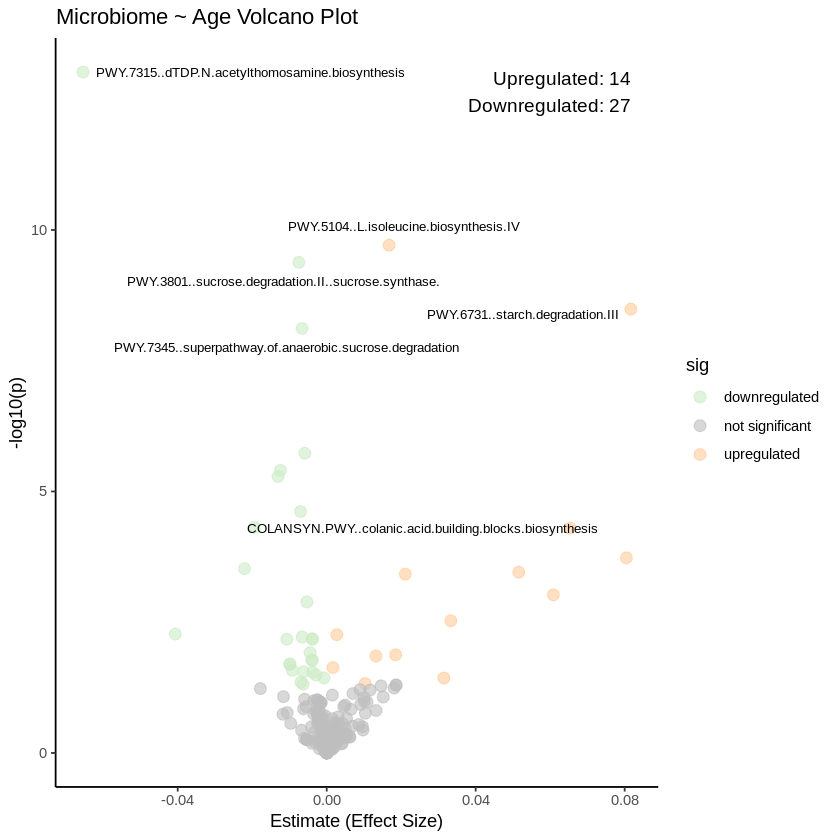

In [11]:
final_result <- final_result %>% 
  mutate(
    sig = case_when(
      !is.na(p) & p < 0.05 & estimate > 0 ~ "upregulated",
      !is.na(p) & p < 0.05 & estimate < 0 ~ "downregulated",
      TRUE ~ "not significant"
    ),
    log_p = -log10(pmax(p, .Machine$double.eps))
  )
top3_upregulated <- final_result %>%
  filter(sig == "upregulated") %>%
  arrange(desc(log_p)) %>%
  head(3)
top3_downregulated <- final_result %>%
  filter(sig == "downregulated") %>%
  arrange(desc(log_p)) %>%
  head(3)
top4_combined <- bind_rows(top3_upregulated, top3_downregulated)
ggplot(final_result, aes(x = estimate, y = log_p)) + 
  geom_point(aes(color = sig), size = 3, alpha = 0.6) +
  scale_color_manual(values = c(
    "upregulated" = "#FFCC99", 
    "downregulated" = "#CCEBC5", 
    "not significant" = "grey"
  )) + 
  theme_classic() + 
  xlab("Estimate (Effect Size)") +
  ylab("-log10(p)") +
  ggtitle("Microbiome ~ Age Volcano Plot") +
  annotate(
    "text",
    x = max(final_result$estimate, na.rm = TRUE),
    y = max(final_result$log_p, na.rm = TRUE),
    label = paste0(
      "Upregulated: ", sum(final_result$sig == "upregulated"), "\n",
      "Downregulated: ", sum(final_result$sig == "downregulated")
    ),
    hjust = 1, vjust = 1, size = 4
  ) +
  geom_text_repel(
    data = top4_combined,
    aes(label = feature),   # <- 这里改成 feature
    size = 2.8,
    color = "black",
    box.padding = 0.5,
    point.padding = 0.5,
    max.overlaps = Inf
  )

In [29]:
class(final_result$p)
length(unique(final_result$p))
head(final_result$p, 20)
length(unique(final_result$padj))

[1] "numeric"

[1] 508

[1] 8.736144e-01 6.629898e-01 7.899729e-01 6.031429e-01 9.208083e-01
 [6] 8.631562e-01 6.899331e-03 8.627471e-05 8.549006e-01 7.682902e-06
[11] 2.195135e-02 8.185710e-01 6.208842e-01 9.640163e-01 8.451885e-01
[16] 3.556105e-02 7.482681e-12 9.561372e-01 1.357717e-06 9.367626e-01

[1] 100

In [30]:
save.image("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_gender.RData")

In [2]:
load("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_gender.RData")

In [3]:
final_result_sig <- final_result %>%
  filter(sig == "sig") %>%
  select(feature, estimate, p, padj)
head(final_result_sig)
dim(final_result_sig)
write_excel_csv(final_result_sig,"/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_age_gender_FDR_sig.csv")

,feature,estimate,p,padj
,<chr>,<dbl>,<dbl>,<dbl>
Estimate7,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,0.080465570,1.863001e-04,8.135105e-03
Estimate28,PWY.241..C4.photosynthetic.carbon.assimilation.cycle..NADP.ME.type,-0.013051528,5.180962e-06,3.393530e-04
Estimate31,PHOSLIPSYN.PWY..superpathway.of.phospholipid.biosynthesis.I..bacteria.,-0.005319361,1.295468e-03,3.993088e-02
Estimate58,HEXITOLDEGSUPER.PWY..superpathway.of.hexitol.degradation..bacteria.,-0.022060617,2.986183e-04,1.203662e-02
Estimate110,PWY.6731..starch.degradation.III,0.081664063,3.264242e-09,4.276157e-07
Estimate132,PWY.3801..sucrose.degradation.II..sucrose.synthase.,-0.007480607,4.160286e-10,7.266634e-08


[1] 17  4